# Task 4 — Cosine vs WSD, 300 Steps, Judge at Step 200


### The two schedules

| | **Cosine** | **WSD** (Warmup-Stable-Decay) |
|---|---|---|
| shape | warmup → cosine decay to `min_lr` over *all* remaining steps | warmup → **flat** at peak LR → short decay over the last ~20% |
| commits to a horizon? | **yes** — the curve is tied to `total_steps` | **no** — the plateau can be cut anywhere and a fresh decay run |
| at an intermediate step | LR already well below peak | LR still at peak (if before the decay window) |

The interesting question is what you have *at step 200 of a 300-step budget*:
cosine has been cooling since warmup; WSD is still at full LR and only starts its
decay at step 240.

In [1]:
import json
import math
import os
import sys
import time
import warnings

sys.path.insert(0, os.path.abspath("../src"))
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from s11.utils import AIM_REPO, get_device, plot_style, savefig, set_seed

plot_style()
set_seed(1337)
DEVICE = get_device()
torch.set_float32_matmul_precision("high")
print(
    f"torch {torch.__version__} | device = {DEVICE} "
    f"| {torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'cpu'}"
)
print(f"Aim repo: {AIM_REPO}  (browse it later with:  uv run aim up)")

torch 2.6.0+cu124 | device = cuda | NVIDIA RTX A6000
Aim repo: /home/ravi.naik/learning/era/ERA/v5/session11/optimizer_experiments  (browse it later with:  uv run aim up)


## 1. Train both (300 steps), plus a WSD variant that decays from 200

In [2]:
from s11.data import load_char_dataset
from s11.trainer import TrainConfig, loss_at_step, train

data = load_char_dataset()
common = {
    "total_steps": 300,
    "warmup": 50,
    "base_lr": 1.5e-3,
    "beta2": 0.99,
    "weight_decay": 0.1,
    "batch_size": 32,
    "eval_interval": 10,
    "eval_iters": 50,
    "ratio_log_interval": 25,
    "device": DEVICE,
    "min_lr_frac": 0.1,
}

print("=== cosine (300) ===")
cos = train(
    data,
    TrainConfig(schedule="cosine", label="cosine_300", **common),
    aim_repo=AIM_REPO,
    experiment="task4_schedules",
)

print("\n=== WSD (300, decay last 20%) ===")
wsd = train(
    data,
    TrainConfig(
        schedule="wsd",
        wsd_decay_frac=0.20,
        wsd_decay_shape="linear",
        label="wsd_300",
        **common,
    ),
    aim_repo=AIM_REPO,
    experiment="task4_schedules",
)

print("\n=== WSD budget=200 (decay 160->200): the 'I decided to stop early' run ===")
c200 = dict(common)
c200["total_steps"] = 200
c200["eval_interval"] = 10
wsd200 = train(
    data,
    TrainConfig(
        schedule="wsd",
        wsd_decay_frac=0.20,
        wsd_decay_shape="linear",
        label="wsd_replan_200",
        **c200,
    ),
    aim_repo=AIM_REPO,
    experiment="task4_schedules",
)

=== cosine (300) ===
  step    0 | lr 3.00e-05 | train 3.7844 | val 3.7986 | gnorm 16.24
  step   10 | lr 3.30e-04 | train 2.8781 | val 2.8987 | gnorm 4.44
  step   20 | lr 6.30e-04 | train 2.6151 | val 2.6163 | gnorm 1.15
  step   30 | lr 9.30e-04 | train 2.5468 | val 2.5471 | gnorm 0.67
  step   40 | lr 1.23e-03 | train 2.5184 | val 2.5378 | gnorm 0.75
  step   50 | lr 1.50e-03 | train 2.5007 | val 2.5032 | gnorm 0.92
  step   60 | lr 1.49e-03 | train 2.4882 | val 2.5145 | gnorm 0.77
  step   70 | lr 1.48e-03 | train 2.4729 | val 2.4907 | gnorm 0.50
  step   80 | lr 1.45e-03 | train 2.4543 | val 2.4770 | gnorm 0.58
  step   90 | lr 1.42e-03 | train 2.4432 | val 2.4735 | gnorm 0.80
  step  100 | lr 1.37e-03 | train 2.4246 | val 2.4626 | gnorm 0.74
  step  110 | lr 1.32e-03 | train 2.3969 | val 2.4221 | gnorm 0.59
  step  120 | lr 1.26e-03 | train 2.3697 | val 2.4070 | gnorm 1.04
  step  130 | lr 1.19e-03 | train 2.3087 | val 2.3374 | gnorm 0.66
  step  140 | lr 1.11e-03 | train 2.2653

## 2. The numbers at step 200 (and at 300)

In [3]:
def at(h, s, k="val_loss"):
    return loss_at_step(h, s, k)


tab = pd.DataFrame(
    [
        {
            "run": "cosine (300-step plan)",
            "val_at_200": at(cos, 200),
            "train_at_200": at(cos, 200, "train_loss"),
            "val_at_300": cos["final"]["val_loss"],
            "lr_at_200": np.interp(200, cos["step"], cos["lr"]),
        },
        {
            "run": "WSD (300-step plan)",
            "val_at_200": at(wsd, 200),
            "train_at_200": at(wsd, 200, "train_loss"),
            "val_at_300": wsd["final"]["val_loss"],
            "lr_at_200": np.interp(200, wsd["step"], wsd["lr"]),
        },
        {
            "run": "WSD (re-planned to 200)",
            "val_at_200": wsd200["final"]["val_loss"],
            "train_at_200": wsd200["final"]["train_loss"],
            "val_at_300": np.nan,
            "lr_at_200": np.interp(199, wsd200["step"], wsd200["lr"]),
        },
    ]
)
print(tab.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print(f"\nΔ(val@200)  WSD-plan minus cosine-plan = {at(wsd, 200) - at(cos, 200):+.4f}")
print(
    f"Δ(val@200)  WSD-replan minus cosine-plan = {wsd200['final']['val_loss'] - at(cos, 200):+.4f}"
)
print(
    f"Δ(val@300)  WSD minus cosine (full plan) = {wsd['final']['val_loss'] - cos['final']['val_loss']:+.4f}"
)

                    run  val_at_200  train_at_200  val_at_300  lr_at_200
 cosine (300-step plan)      2.0728        1.9867      1.9204     0.0006
    WSD (300-step plan)      2.0856        1.9883      1.8447     0.0015
WSD (re-planned to 200)      2.0412        1.9555         NaN     0.0002

Δ(val@200)  WSD-plan minus cosine-plan = +0.0128
Δ(val@200)  WSD-replan minus cosine-plan = -0.0316
Δ(val@300)  WSD minus cosine (full plan) = -0.0757


## 3. Charts

  saved assets/t4_cosine_vs_wsd.png


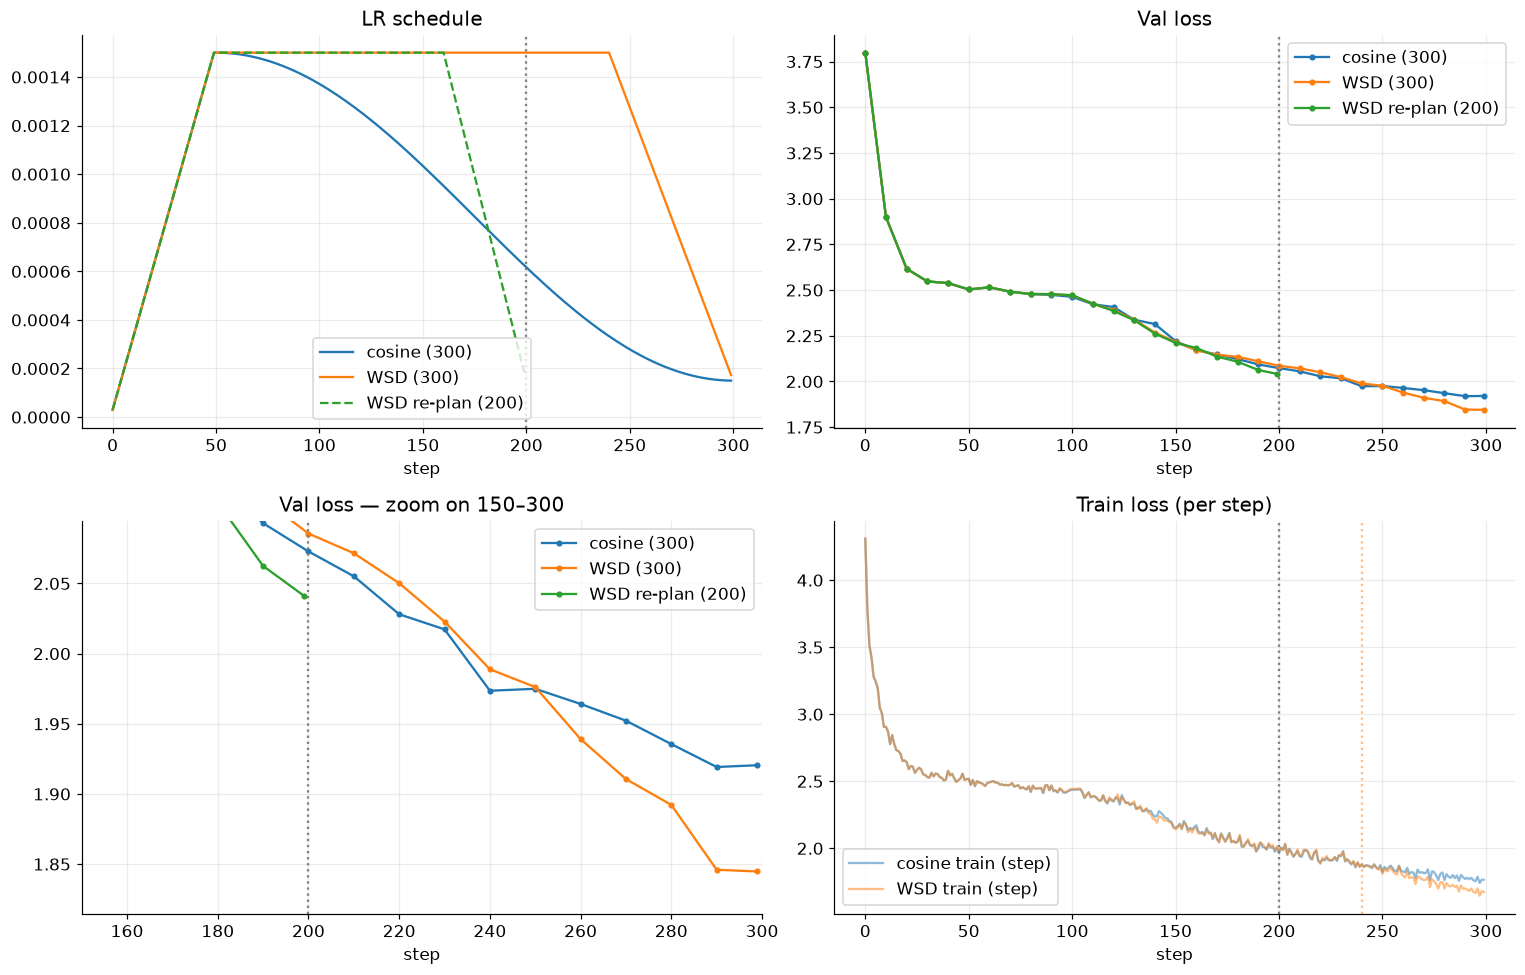

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

ax[0, 0].plot(cos["step"], cos["lr"], label="cosine (300)")
ax[0, 0].plot(wsd["step"], wsd["lr"], label="WSD (300)")
ax[0, 0].plot(wsd200["step"], wsd200["lr"], ls="--", label="WSD re-plan (200)")
ax[0, 0].axvline(200, color="grey", ls=":")
ax[0, 0].set_title("LR schedule")
ax[0, 0].set_xlabel("step")
ax[0, 0].legend()

for h, lab in [
    (cos, "cosine (300)"),
    (wsd, "WSD (300)"),
    (wsd200, "WSD re-plan (200)"),
]:
    ax[0, 1].plot(h["eval_step"], h["val_loss"], marker=".", label=lab)
ax[0, 1].axvline(200, color="grey", ls=":")
ax[0, 1].set_title("Val loss")
ax[0, 1].set_xlabel("step")
ax[0, 1].legend()

for h, lab in [
    (cos, "cosine (300)"),
    (wsd, "WSD (300)"),
    (wsd200, "WSD re-plan (200)"),
]:
    ax[1, 0].plot(h["eval_step"], h["val_loss"], marker=".", label=lab)
ax[1, 0].set_xlim(150, 300)
lo = min(min(cos["val_loss"][-8:]), min(wsd["val_loss"][-8:]))
ax[1, 0].set_ylim(lo - 0.03, lo + 0.25)
ax[1, 0].axvline(200, color="grey", ls=":")
ax[1, 0].set_title("Val loss — zoom on 150–300")
ax[1, 0].set_xlabel("step")
ax[1, 0].legend()

ax[1, 1].plot(
    cos["step"], cos["train_loss_step"], alpha=0.5, label="cosine train (step)"
)
ax[1, 1].plot(wsd["step"], wsd["train_loss_step"], alpha=0.5, label="WSD train (step)")
ax[1, 1].axvline(200, color="grey", ls=":")
ax[1, 1].axvline(240, color="C1", ls=":", alpha=0.5)
ax[1, 1].set_title("Train loss (per step)")
ax[1, 1].set_xlabel("step")
ax[1, 1].legend()

plt.tight_layout()
savefig(fig, "t4_cosine_vs_wsd.png")
plt.show()

## 4. Which model would I keep?

*(Exact losses printed above; measured on this run.)*

| checkpoint | val loss | when |
|---|---|---|
| cosine, stopped at 200 | **2.073** | LR already decayed to 6.2e-4 |
| WSD (300-plan), stopped at 200 | **2.086** | still on the 1.5e-3 plateau |
| **WSD re-planned to a 200 budget** | **2.041** | got a real 40-step decay |
| cosine, full 300 | 1.920 | |
| **WSD, full 300** | **1.845** | |

**Reading it**

- **Frozen at step 200 of a 300-step plan**, cosine (2.073) edges out plateau-WSD
  (2.086) — cosine has been annealing for 150 steps, WSD has not. That 0.013 gap
  is the "you stopped me mid-plateau" penalty, and it is small.
- **The fair comparison** (assignment's own warning: *tune both sides*): if you
  actually decide to stop at 200, you tell WSD that up front and it decays over
  160→200. That **WSD-replanned checkpoint (2.041) beats cosine-at-200**, because
  it ran at a higher LR for longer and still got its cooldown.
- **At the full horizon WSD wins outright here** (1.845 vs 1.920, a 0.076 gap) —
  the long 1.5e-3 plateau does more useful work than cosine's immediate decay on
  this short, well-warmed budget.

**Decision: keep WSD.** Concretely, keep the **WSD, full-300** checkpoint (lowest
loss, 1.845). If forced to stop at exactly step 200 with no re-plan, keep the
**cosine-200** checkpoint by a hair — but the moment you can choose your stopping
point, WSD's re-plannable plateau is strictly better here, and it removes the
"pick the horizon before you start" commitment that cosine forces on you.